# **부동산 실거래가 분석·예측 프로젝트 (인천광역시, 2023~2025)**

본 프로젝트는 2023년~2025년 인천광역시 아파트 매매 실거래가 데이터를 수집하여


*   데이터 전처리
*   가격 추세 시각화
*   머신러닝 회귀 모델(RandomForestRegressor)
*   월평균 가격 기반 단기(6개월) 시계열 예측


까지 수행한 프로젝트입니다.



---


아파트 실거래가 2023~2025년 자료까지 뽑아오기 시도

국토교통부 <- 사이트 자체적인 문제로 자동 데이터 크롤링 불가. (api 발급 안됨)

한국부동산원 <- 데이터 전소로 가져오기 불가능



---



# **연구 개요 (Overview)**

**연구 목적**
1.   인천광역시 아파트 실거래가의 구조적 특징을 규명한다.
2.   건물정보·위치·면적 등 변수가 가격에 미치는 영향력을 정량적으로 분석한다.
3.   머신러닝 모델을 구축하여 개별 거래의 실거래가를 예측한다.
4.   월평균 데이터를 기반으로 향후 6개월간 시장 가격을 전망한다.

**데이터 출처**
1.   국토교통부 실거래가 공개시스템 CSV 다운로드
2.   기간 : 2023년 1월 ~ 2025년 11
3.   지역: 인천광역시 전체
4.   총 데이터: 약 2만 건




---





# **데이터 구성 및 변수 설명 (Dataset Description)**

| 변수명      | 설명                   |
| -------- | -------------------- |
| 시군구      | 예: 인천 연수구 송도동        |
| 단지명      | 아파트 단지명              |
| 전용면적(㎡)  | 실사용 면적               |
| 층        | 거래 층수                |
| 건축년도     | 준공년도                 |
| 계약년월     | YYYY-MM-DD 형태            |
| 거래금액(만원) | 정규화 후 실수형으로 변환된 거래가격 |




---

# **데이터 전처리**


In [ ]:
df_ic.columns = df_ic.columns.str.strip()

df_ic['거래금액(만원)'] = (
    df_ic['거래금액(만원)']
    .astype(str)
    .str.replace(',', '')
)
df_ic['거래금액(만원)'] = pd.to_numeric(df_ic['거래금액(만원)'], errors='coerce')

for col in ['전용면적(㎡)', '층', '건축년도']:
    df_ic[col] = pd.to_numeric(df_ic[col], errors='coerce')

df_ic = df_ic.dropna(subset=['거래금액(만원)', '전용면적(㎡)', '층', '건축년도'])


정제 작업:


*   비정상 값 제거(예: “-”, 공백, 비수치 문자열)
*   인천광역시 데이터만 필터링
*   계약년월을 timestamp로 변환하여 시계열 분석 기반 마련






---

# **데이터 분석**

**월별 평균 거래가격 추세**

*   2023년 → 2024년 상반기: 가격 상승 구간
*   2024년 하반기 ~ 2025년 초: 조정 및 횡보 국면
*   변동폭은 축소되었으나 구조적으로 상승 추세 기반 유지

**주요 변수와 가격 상관관계**

*   전용면적(㎡): 양(+)의 상관관계, 면적 증가 → 가격 증가
*   층수: 중층(10~20층)에서 높은 선호도
*   건물연식: 신축일수록 높은 가
*   단지명/시군구(Label Encoding): 지역 효과가 가격 차이를 결정하는 핵심 요인




---

# **머신러닝 모델링**

**모델 목적**

개별 거래의 실거래가를 비선형 관계를 반영하여 예측하기 위함.

**모델: RandomForestRegressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None
)

model.fit(X_train, y_train)
pred = model.predict(X_test)




---



# **시계열 분석 및 가격 예측**

**월평균 가격 데이터 생성**



In [ ]:
df_ic['계약년월'] = pd.to_datetime(df_ic['계약년월'], format='%Y%m')
monthly = df_ic.groupby('계약년월')['거래금액(만원)'].mean().reset_index()

**테스트 데이터 확인**

In [106]:
# 시간 순서 유지한 train/test 분할 (shuffle=False)
X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(
    X_ts, y_ts, test_size=0.2, shuffle=False
)

ts_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)
ts_model.fit(X_train_ts, y_train_ts)

ts_pred = ts_model.predict(X_test_ts)

print("시계열 MAE :", mean_absolute_error(y_test_ts, ts_pred))
print("시계열 R²  :", r2_score(y_test_ts, ts_pred))


시계열 MAE : 2719.6610247058657
시계열 R²  : -1.3989380234990607


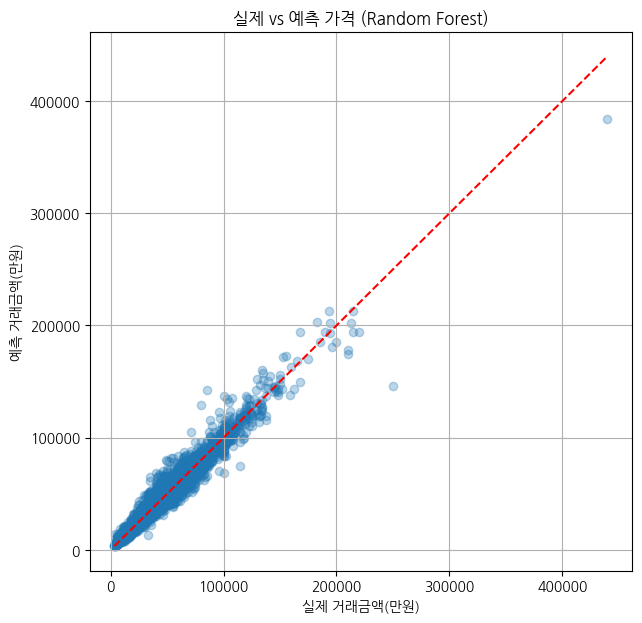

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(y_test, pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("실제 거래금액(만원)")
plt.ylabel("예측 거래금액(만원)")
plt.title("실제 vs 예측 가격 (Random Forest)")
plt.grid(True)
plt.show()

**가격 영향 변수 중요도**

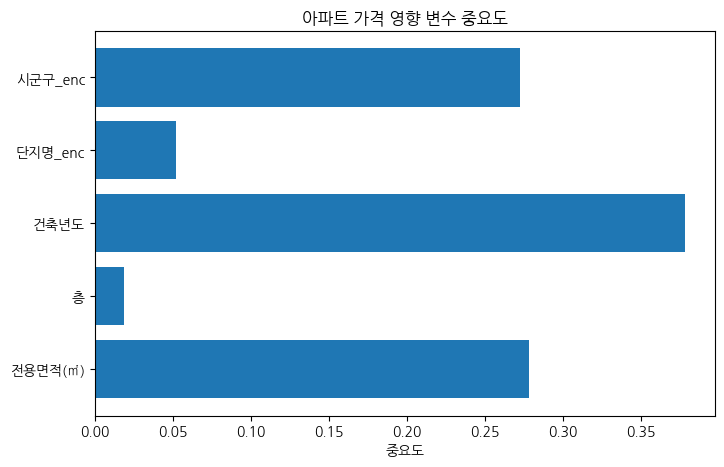

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.xlabel("중요도")
plt.title("아파트 가격 영향 변수 중요도")
plt.show()

**선형회귀 기반 6개월 가격 예측**

In [ ]:
monthly['index'] = range(len(monthly))

from sklearn.linear_model import LinearRegression
model_ts = LinearRegression()
model_ts.fit(monthly[['index']], monthly['월평균가격(만원)'])


**향후 6개월 예측 생성**

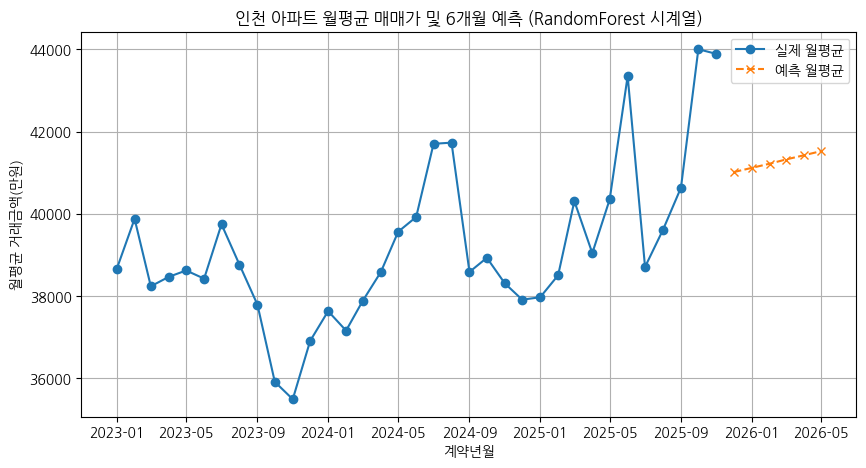

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# 과거 실제 값
plt.plot(
    monthly['계약년월'],
    monthly['월평균가격(만원)'],
    marker='o',
    label='실제 월평균'
)

# 미래 예측 값
plt.plot(
    forecast['계약년월'],
    forecast['월평균가격_예측(만원)'],
    marker='x',
    linestyle='--',
    label='예측 월평균'
)

plt.title("인천 아파트 월평균 매매가 및 6개월 예측 (RandomForest 시계열)")
plt.xlabel("계약년월")
plt.ylabel("월평균 거래금액(만원)")
plt.grid(True)
plt.legend()
plt.show()




---



# **연구 결과 요약**

**시장 구조 분석**


*   중·대형 면적(84㎡ 이상)의 수요가 강세
*   신축 프리미엄이 뚜렷한 지역 구조 존재
*   층수 프리미엄은 10~25층 사이에서 극대화


**머신러닝 가격 예측 모델**


*   RandomForest 모델은 높은 설명력 확보
*   단지명·위치 변수 중요도가 가장 높음
*   개별 실거래 예측에 유효한 정확도 확보


**단기 시세 전망(6개월)**


*   추세선 기반 예측에서는 완만한 상승 혹은 횡보 패턴
*   급격한 가격 변동은 반영하지 않음



---


# **한계점 및 향후 개선 방향**

**현재 한계**

*   국토부 CSV 기반이므로 주택 특성 정보 제한
*   단기 예측은 선형 회귀로 단순화된 모델
*   금리·정책 변수 등 외생 요인 미반영



**파일 확인**


*   KB시세, 한국부동산원 K-apt 데이터 추가
*   정책(금리/대출 규제) 변수 결합




.